# Деревья решений: прогнозирование одобрения кредита

**Датасет:** `train.csv` (кредитные заявки)  
**Целевая переменная:** `Loan_Status` - `1` = Approved (одобрена), `0` = Rejected (отклонена)  
**Модель:** `DecisionTreeClassifier`

# 1. Загрузка и предварительный анализ данных


## 1.1. Загрузка данных и структура датасета


In [334]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

sns.set_theme(style="whitegrid")
np.random.seed(42)
pd.set_option("display.max_columns", 50)

DATA_PATH = "train.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Размер:", df_raw.shape)
df_raw.head()


Размер: (3192, 14)


,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [335]:
# Типы данных и пропуски
print("=== info ===")
df_raw.info()
print("\n=== пропуски ===")
print(df_raw.isna().sum().sort_values(ascending=False))
print("\nВсего пропусков:", int(df_raw.isna().sum().sum()))


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             3192 non-null   object 
 1   Gender              3115 non-null   object 
 2   Married             3126 non-null   object 
 3   Dependents          3192 non-null   int64  
 4   Education           3126 non-null   object 
 5   Employment_Status   3136 non-null   object 
 6   Applicant_Income    3157 non-null   float64
 7   Coapplicant_Income  3192 non-null   float64
 8   Loan_Amount         3151 non-null   float64
 9   Loan_Term           3192 non-null   int64  
 10  Credit_History      3192 non-null   int64  
 11  Property_Area       3192 non-null   object 
 12  Age                 3192 non-null   float64
 13  Loan_Status         3192 non-null   object 
dtypes: float64(4), int64(3), object(7)
memory usage: 349.2+ KB

=== пропуски ===
Gender        

**Что видно:** есть пропуски в `Gender`, `Married`, `Education`, `Employment_Status`, `Applicant_Income`, `Loan_Amount`.  
`Credit_History` и `Dependents` заполнены полностью. `Loan_ID` — идентификатор, для модели не нужен.

Обработку пропусков (медиана / мода) делаем в **п. 1.3** по заданию — после EDA.


## 1.2. Целевая переменная и зависимости


Распределение Loan_Status:
Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64
Loan_Status_num
1    0.5
0    0.5
Name: proportion, dtype: float64


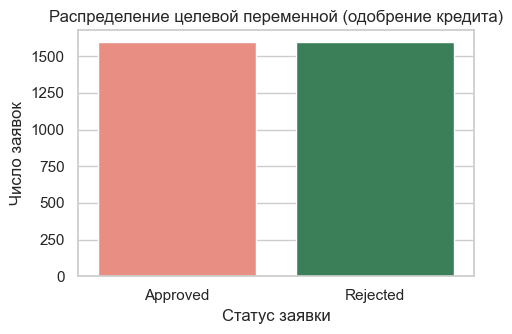

In [336]:
# Loan_Status: Approved/Rejected - для анализа сразу сделаем копию с 0/1
df = df_raw.copy()
df["Loan_Status_num"] = df["Loan_Status"].map({"Approved": 1, "Rejected": 0})

print("Распределение Loan_Status:")
print(df["Loan_Status"].value_counts())
print(df["Loan_Status_num"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x="Loan_Status", hue="Loan_Status", palette=["salmon", "seagreen"], legend=False, ax=ax)
ax.set_title("Распределение целевой переменной (одобрение кредита)")
ax.set_xlabel("Статус заявки")
ax.set_ylabel("Число заявок")
plt.tight_layout()
plt.show()


Вывод: классы сбалансированы 50/50 — удобно для accuracy, но всё равно смотрим precision/recall/F1.

Доля Approved/Rejected при Credit_History=0/1:
Loan_Status     Approved  Rejected
Credit_History                    
0                  0.001     0.999
1                  0.967     0.033


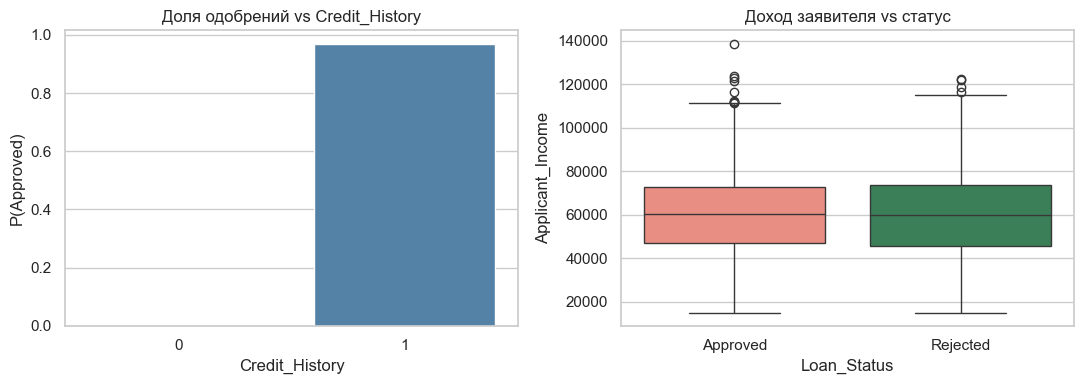

In [337]:
# Смотрим, как часто одобряют заявку при разной кредитной истории:
# 0 — кредитная история плохая/нет, 1 — история хорошая.
# normalize="index" означает: внутри каждого значения Credit_History считаем доли Approved/Rejected.
ct = pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index")
print("Доля Approved/Rejected при Credit_History=0/1:")
print(ct.round(3))

# Создаём 2 графика в одной строке: слева — доля одобрений, справа — доход по статусу заявки.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Слева: смотрим, насколько сильно Credit_History влияет на вероятность одобрения.
# y = Loan_Status_num: 1 = Approved, 0 = Rejected, поэтому среднее значение показывает долю одобрения.
sns.barplot(data=df, x="Credit_History", y="Loan_Status_num", errorbar=None, ax=axes[0], color="steelblue")
axes[0].set_title("Доля одобрений vs Credit_History")
axes[0].set_ylabel("P(Approved)")

# Справа: сравниваем распределение дохода у одобренных и отклонённых заявок.
# Если медианы или коробки заметно отличаются, это тоже может быть полезным признаком.
sns.boxplot(data=df, x="Loan_Status", y="Applicant_Income", ax=axes[1],
            hue="Loan_Status", palette=["salmon", "seagreen"], legend=False)
axes[1].set_title("Доход заявителя vs статус")
plt.tight_layout()
plt.show()

Вывод: Credit_History сильно связан с одобрением (при 0 одобряют реже).<br>
По доходу разница слабее — дерево уточнит важность признаков.

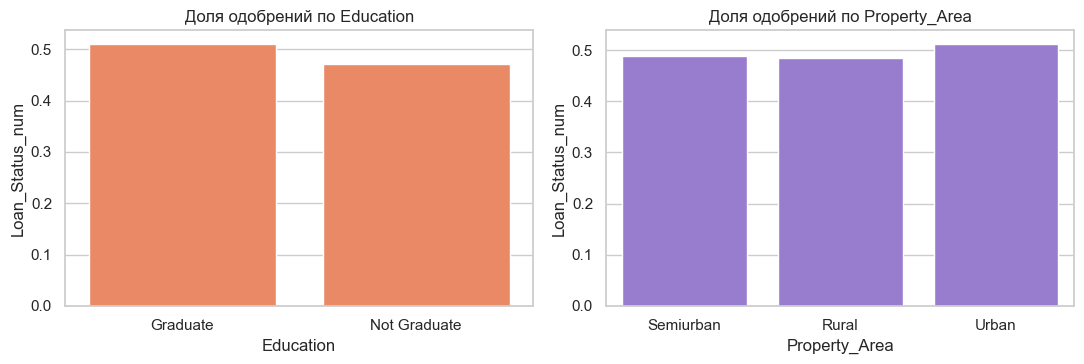

In [338]:
# Ещё пара срезов: образование и район недвижимости
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.barplot(data=df, x="Education", y="Loan_Status_num", errorbar=None, ax=axes[0], color="coral")
axes[0].set_title("Доля одобрений по Education")
sns.barplot(data=df, x="Property_Area", y="Loan_Status_num", errorbar=None, ax=axes[1], color="mediumpurple")
axes[1].set_title("Доля одобрений по Property_Area")
plt.tight_layout()
plt.show()


- **Education:** доля одобрений у `Graduate` ≈ **51%**, у `Not Graduate` ≈ **47%**. Высшее образование связано с чуть большей вероятностью одобрения, но разница небольшая.
- **Property_Area:** Semiurban ≈ **49%**, Urban ≈ **51%**, Rural ≈ **48%**. Район недвижимости тоже сдвигает шансы — это полезный категориальный признак.
- **Итог:** оба фактора влияют слабее, чем `Credit_History`, но для дерева их имеет смысл оставить и закодировать (`get_dummies`).


## 1.3. Предобработка данных


In [339]:
# --- Удаляем Loan_ID ---
work = df_raw.drop(columns=["Loan_ID"]).copy()

# --- Целевая: Approved - 1, Rejected - 0 ---
work["Loan_Status"] = work["Loan_Status"].map({"Approved": 1, "Rejected": 0})
assert work["Loan_Status"].isna().sum() == 0

print("Loan_ID удалён. Loan_Status закодирован как 0/1.")
print(work["Loan_Status"].value_counts())
print("\nПропуски до заполнения:")
print(work.isna().sum()[work.isna().sum() > 0])


Loan_ID удалён. Loan_Status закодирован как 0/1.
Loan_Status
1    1596
0    1596
Name: count, dtype: int64

Пропуски до заполнения:
Gender               77
Married              66
Education            66
Employment_Status    56
Applicant_Income     35
Loan_Amount          41
dtype: int64


### Заполнение числовых пропусков: медиана + индикатор

Для `Loan_Amount` и `Applicant_Income`:
1. сначала запоминаем, **где был пропуск** (флаг 0/1);
2. затем заполняем **медианой**.

Так модель видит и типичное значение, и сам факт «данных не было».


In [340]:
# --- Числовые пропуски: индикатор + медиана ---
num_cols_with_na = ["Loan_Amount", "Applicant_Income"]

for col in num_cols_with_na:
    work[f"{col}_was_missing"] = work[col].isna().astype(int)
    median_val = work[col].median()
    n_na = int(work[f"{col}_was_missing"].sum())
    work[col] = work[col].fillna(median_val)
    print(f"{col}: NaN = {n_na} - медиана = {median_val:.2f}; добавлен флаг {col}_was_missing")

print("\nПропусков в этих числах сейчас:",
      int(work[num_cols_with_na].isna().sum().sum()))


Loan_Amount: NaN = 41 - медиана = 151967.79; добавлен флаг Loan_Amount_was_missing
Applicant_Income: NaN = 35 - медиана = 60290.18; добавлен флаг Applicant_Income_was_missing

Пропусков в этих числах сейчас: 0


### Заполнение категориальных пропусков модой

Для `Gender`, `Married`, `Education`, `Employment_Status` подставляем **моду**.  


In [341]:
# --- Категориальные пропуски: мода ---
cat_cols_fill = ["Gender", "Married", "Education", "Employment_Status"]

for col in cat_cols_fill:
    n_na = int(work[col].isna().sum())
    if n_na == 0:
        print(f"{col}: пропусков нет")
        continue
    mode_val = work[col].mode(dropna=True)[0]
    work[col] = work[col].fillna(mode_val)
    print(f"{col}: NaN = {n_na} - мода = '{mode_val}'")

print(f"\nCredit_History: пропусков = {work['Credit_History'].isna().sum()} (заполнение не требуется)")
print(f"Dependents: пропусков = {work['Dependents'].isna().sum()} (уже число 0..3)")
print("\nВсего пропусков в work после заполнения:", int(work.isna().sum().sum()))


Gender: NaN = 77 - мода = 'Male'
Married: NaN = 66 - мода = 'Yes'
Education: NaN = 66 - мода = 'Graduate'
Employment_Status: NaN = 56 - мода = 'Salaried'

Credit_History: пропусков = 0 (заполнение не требуется)
Dependents: пропусков = 0 (уже число 0..3)

Всего пропусков в work после заполнения: 0


In [342]:
# --- Кодирование категориальных признаков (get_dummies) ---
# Credit_History оставляем 0/1; Dependents — число 0..3
cat_to_dummy = ["Gender", "Married", "Education", "Employment_Status", "Property_Area"]

print("Размер до get_dummies:", work.shape)


work_enc = pd.get_dummies(work, columns=cat_to_dummy, drop_first=True, dtype=int)

print("Размер после get_dummies:", work_enc.shape)
print("Колонки:")
print(list(work_enc.columns))


Размер до get_dummies: (3192, 15)
Размер после get_dummies: (3192, 17)
Колонки:
['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Age', 'Loan_Status', 'Loan_Amount_was_missing', 'Applicant_Income_was_missing', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Employment_Status_Self-Employed', 'Employment_Status_Unemployed', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [343]:
# --- X / y и train-test split 80/20 ---
y = work_enc["Loan_Status"]
X = work_enc.drop(columns=["Loan_Status"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "доля Approved =", round(y_train.mean(), 3))
print("Test: ", X_test.shape, "доля Approved =", round(y_test.mean(), 3))
print("Признаков:", X.shape[1])


Train: (2553, 16) доля Approved = 0.5
Test:  (639, 16) доля Approved = 0.499
Признаков: 16


### Комментарий: как предобработка повлияла на данные

1. Убрали **Loan_ID** — модель не учит номера заявок.  
2. Пропуски обработали **в п. 1.3**: числа — **медиана + индикатор пропуска**; категории — **мода**. Строки не выбрасывали.  
3. Текст (`Gender`, `Married`, …) превратили в **0/1** через `get_dummies`.  
4. Target стал **0/1**, split **80/20** со `stratify=y`.  
5. Датасет готов к `fit`.


# 2. Построение базовой модели дерева решений

Обучаем `DecisionTreeClassifier` **с параметрами по умолчанию** (без ограничения глубины — дерево может вырасти «до листьев»).

Отдельного `test.csv` в папке нет — предсказания и метрики считаем на **тестовой части** (20%), полученной в п. 1.3.


## 2.1. Обучение модели и предсказания


In [344]:
# 2.1. Базовая модель (default)

# Создаём дерево решений «как есть», без ручных ограничений глубины
tree_default = DecisionTreeClassifier(random_state=42)

# Учим модель на обучающей выборке: ищем правила «если признак … - одобрить/отклонить»
tree_default.fit(X_train, y_train)

# На тестовой выборке получаем ответы модели: 0 = Rejected, 1 = Approved
y_pred_def = tree_default.predict(X_test)

# Те же предсказания на train — потом сравним с test и поймём, нет ли переобучения
y_pred_train_def = tree_default.predict(X_train)

print("Глубина дерева:", tree_default.get_depth())
print("Число листьев:", tree_default.get_n_leaves())
print("Модель обучена.")
print("Пример предсказаний на test (первые 20):", y_pred_def[:20])


Глубина дерева: 9
Число листьев: 34
Модель обучена.
Пример предсказаний на test (первые 20): [0 0 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1]


## 2.2. Оценка качества модели

Считаем **Accuracy** и для класса **1 (Approved)**: Precision, Recall, F1-score.  
Также смотрим метрики на train — большой разрыв с test подскажет переобучение.


In [345]:
# 2.2. Метрики (класс 1 = Approved)

# Вспомогательная функция: считает метрики и складывает их в словарь
def eval_model(name, y_true, y_pred, y_train_true=None, y_train_pred=None):
    
    # Сюда положим все числа качества для одной модели
    row = {
        "model": name,  # имя модели (для таблицы сравнения)
        # Доля всех правильных ответов на переданной выборке (обычно test)
        "accuracy": accuracy_score(y_true, y_pred),
        # Из всех, кого назвали Approved, какая доля правда Approved
        "precision_1": precision_score(y_true, y_pred, pos_label=1),
        # Из всех реальных Approved, какую долю модель нашла
        "recall_1": recall_score(y_true, y_pred, pos_label=1),
        # Баланс precision и recall для класса Approved
        "f1_1": f1_score(y_true, y_pred, pos_label=1),
    }
    
    # Если передали предсказания на train — добавим метрики и для него
    if y_train_true is not None:
        # Accuracy на обучении (если сильно выше test — подозрение на переобучение)
        row["accuracy_train"] = accuracy_score(y_train_true, y_train_pred)
        # F1 по Approved на обучении
        row["f1_1_train"] = f1_score(y_train_true, y_train_pred, pos_label=1)
    
    return row

# Считаем метрики для нашего дерева по умолчанию (test + train)
metrics_def = eval_model(
    "default_tree", y_test, y_pred_def, y_train, y_pred_train_def
)

# Превращаем словарь в таблицу pandas — так удобнее смотреть и сравнивать модели
metrics_table = pd.DataFrame([metrics_def])

print("=== Таблица метрик (default tree) ===")
# Какие столбцы показать в таблице
display_cols = ["model", "accuracy_train", "accuracy", "precision_1", "recall_1", "f1_1", "f1_1_train"]
print(metrics_table[display_cols].round(4).to_string(index=False))
print()
print(classification_report(y_test, y_pred_def, target_names=["Rejected(0)", "Approved(1)"]))


=== Таблица метрик (default tree) ===
       model  accuracy_train  accuracy  precision_1  recall_1   f1_1  f1_1_train
default_tree             1.0    0.9656       0.9569    0.9749 0.9658         1.0

              precision    recall  f1-score   support

 Rejected(0)       0.97      0.96      0.97       320
 Approved(1)       0.96      0.97      0.97       319

    accuracy                           0.97       639
   macro avg       0.97      0.97      0.97       639
weighted avg       0.97      0.97      0.97       639



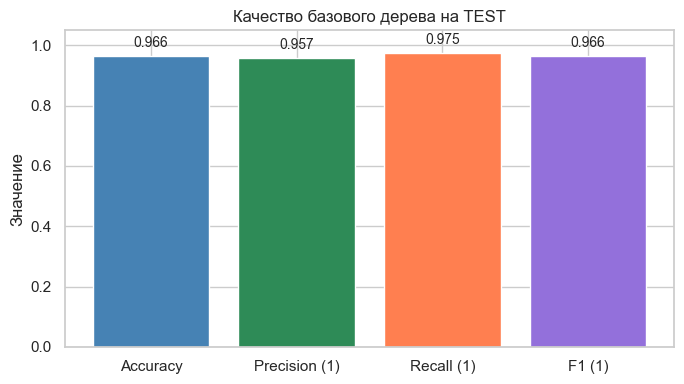

In [346]:
# График метрик на test (Accuracy / Precision / Recall / F1)

# Ключи метрик из словаря metrics_def
metric_names = ["accuracy", "precision_1", "recall_1", "f1_1"]
# Подписи столбцов на графике (понятнее, чем имена переменных)
metric_labels = ["Accuracy", "Precision (1)", "Recall (1)", "F1 (1)"]
# Достаём числовые значения метрик в том же порядке
values = [metrics_def[m] for m in metric_names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metric_labels, values, color=["steelblue", "seagreen", "coral", "mediumpurple"])
# Ограничиваем ось Y от 0 до 1 (метрики в долях), чуть выше — место для подписей
ax.set_ylim(0, 1.05)
ax.set_ylabel("Значение")
ax.set_title("Качество базового дерева на TEST")
# Над каждым столбцом пишем число метрики
for b, v in zip(bars, values):
    # Координата текста: центр столбца по X, чуть выше вершины по Y
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


## 2.3. Матрица ошибок


Confusion matrix [[TN FP],[FN TP]]:
[[306  14]
 [  8 311]]

TN (верно Rejected) = 306
FP (ложное Approved) = 14
FN (пропущенный Approved) = 8
TP (верно Approved) = 311


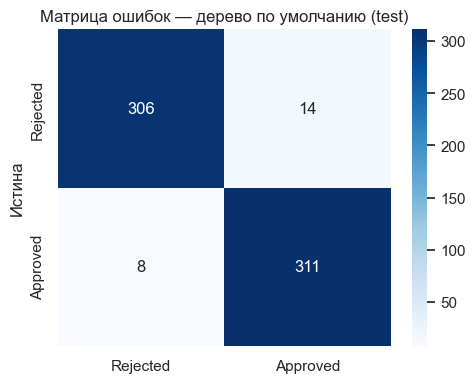

In [347]:
# 2.3. Матрица ошибок

# Считаем, сколько раз модель угадала / ошиблась по классам (на test)
cm_def = confusion_matrix(y_test, y_pred_def)
print("Confusion matrix [[TN FP],[FN TP]]:")
print(cm_def)
print()
# Распаковываем матрицу в четыре числа: TN, FP, FN, TP
tn, fp, fn, tp = cm_def.ravel()
print(f"TN (верно Rejected) = {tn}")
print(f"FP (ложное Approved) = {fp}")
print(f"FN (пропущенный Approved) = {fn}")
print(f"TP (верно Approved) = {tp}")

# Новая фигура для тепловой карты
plt.figure(figsize=(5, 4))
# Рисуем матрицу ошибок: цвет = число, annot=True — пишем цифры в клетках
sns.heatmap(
    cm_def, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Rejected", "Approved"],  # подписи по оси предсказаний
    yticklabels=["Rejected", "Approved"],  # подписи по оси истины
)
# Подпись оси X — что предсказала модель
plt.ylabel("Истина")
plt.title("Матрица ошибок — дерево по умолчанию (test)")
plt.tight_layout()
plt.show()


### Вывод по п.2

- Базовое дерево с параметрами по умолчанию часто даёт **очень высокий score на train** (вплоть до 1.0) и более скромный на **test**.  
- Это классический признак **переобучения**: дерево слишком глубокое и запомнило обучающую выборку.  
- Метрики для класса **Approved (1)** и матрица ошибок сохранены выше (таблица + графики).  
- В п.3 подтвердим переобучение численно (глубина, листья, разрыв train−test) и посмотрим структуру дерева.


# 3. Визуализация и интерпретация дерева


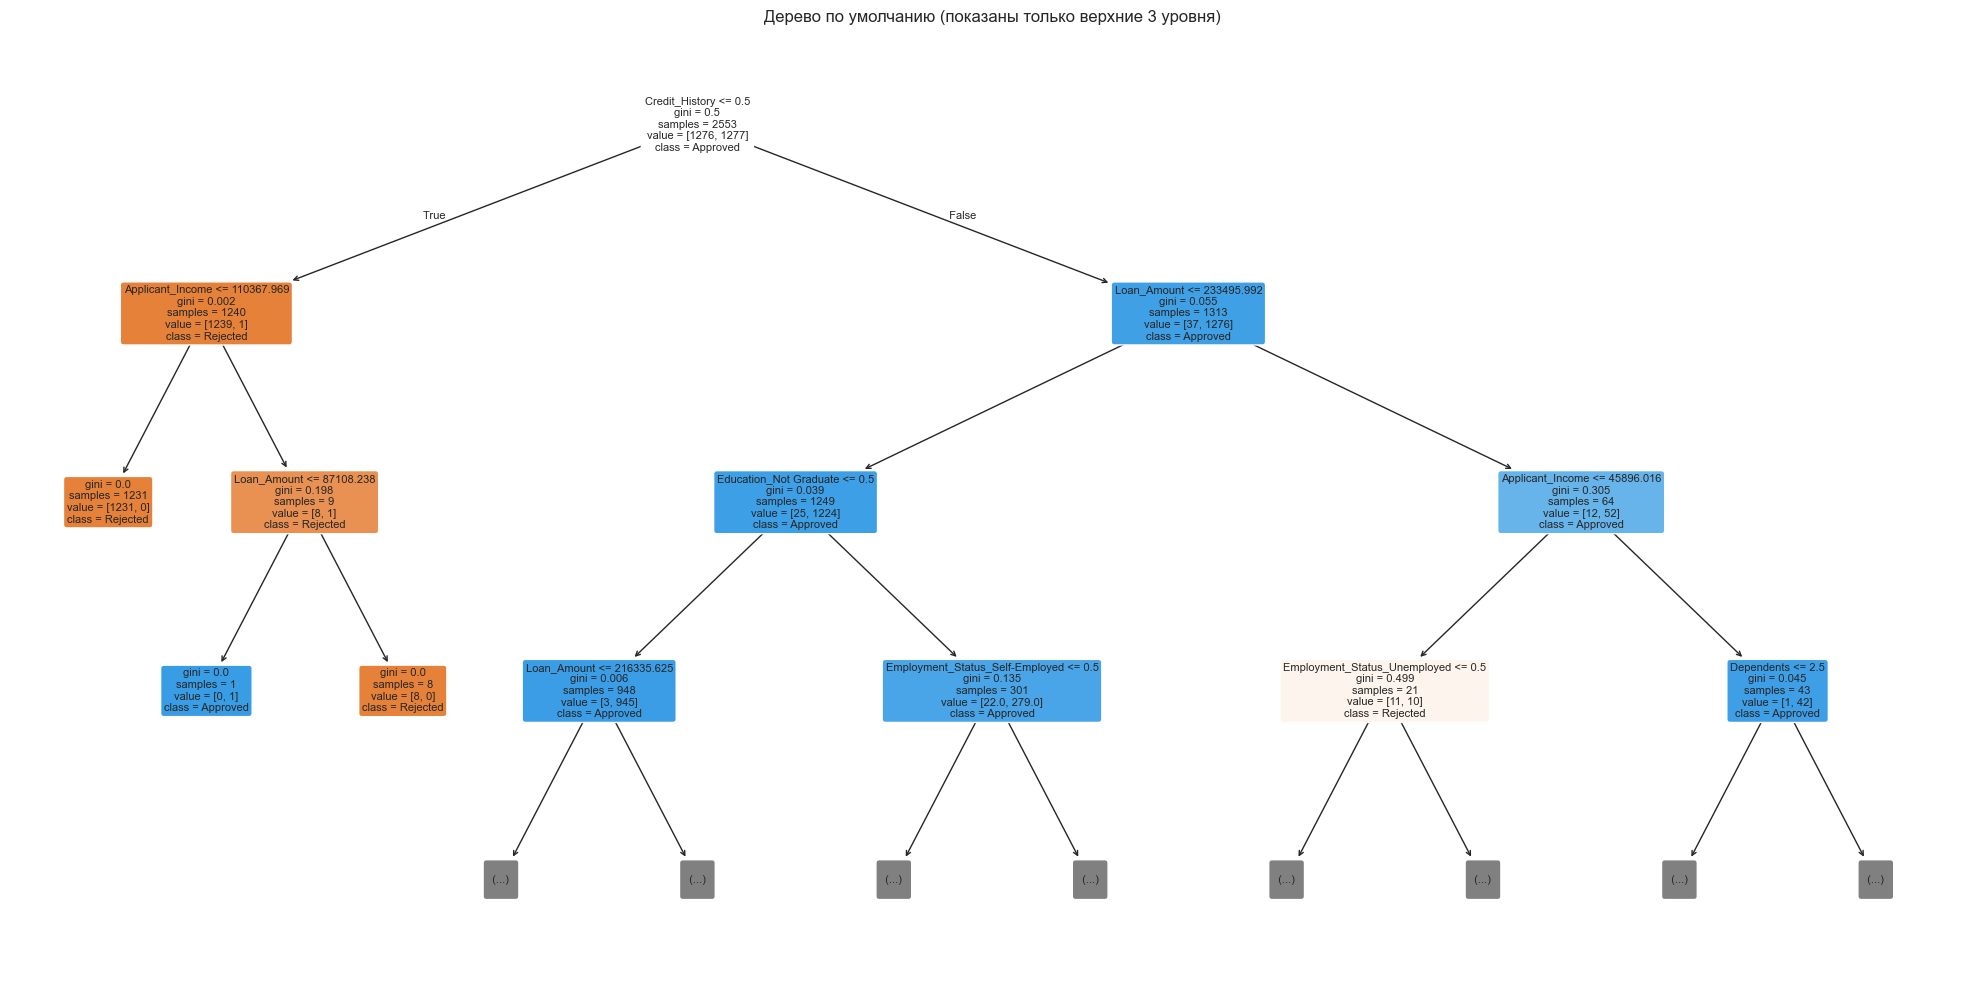

Первое разбиение (корень): признак = 'Credit_History', порог ≈ 0.5000


In [348]:
# 3.1. plot_tree с max_depth=3 (для читаемости)
plt.figure(figsize=(20, 10))
plot_tree(
    tree_default,
    max_depth=3,
    feature_names=list(X.columns),
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Дерево по умолчанию (показаны только верхние 3 уровня)")
plt.tight_layout()
plt.show()

# Первое разбиение
root_feat = X.columns[tree_default.tree_.feature[0]]
root_thr = tree_default.tree_.threshold[0]
print(f"Первое разбиение (корень): признак = '{root_feat}', порог ≈ {root_thr:.4f}")


Топ-10 важных признаков (default tree):
Credit_History                     0.9421
Applicant_Income                   0.0145
Loan_Amount                        0.0111
Coapplicant_Income                 0.0110
Property_Area_Urban                0.0069
Employment_Status_Self-Employed    0.0057
Age                                0.0031
Employment_Status_Unemployed       0.0018
Education_Not Graduate             0.0018
Gender_Male                        0.0010
dtype: float64


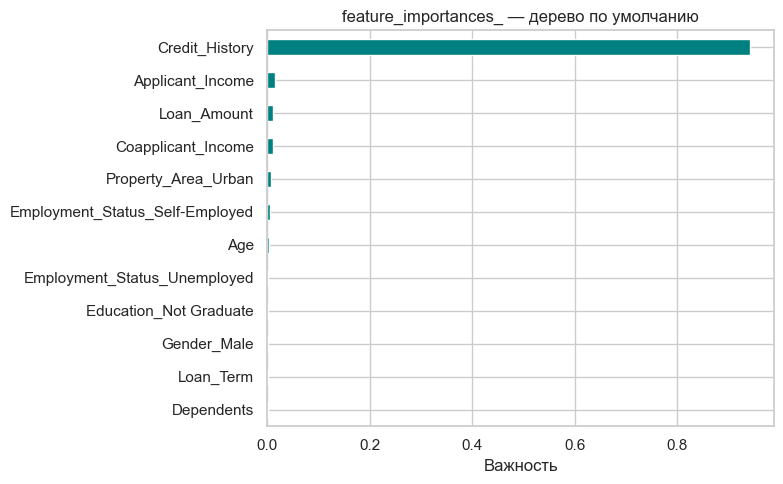

In [349]:
# 3.2. Важность признаков (feature_importances_)
imp_def = pd.Series(tree_default.feature_importances_, index=X.columns)
imp_def = imp_def.sort_values(ascending=False)

print("Топ-10 важных признаков (default tree):")
print(imp_def.head(10).round(4))

plt.figure(figsize=(8, 5))
imp_def.head(12).sort_values().plot(kind="barh", color="teal")
plt.title("feature_importances_ — дерево по умолчанию")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()


In [350]:
# 3.3. Сравним train и test численно, чтобы выявить переобучение
gap_acc = metrics_def["accuracy_train"] - metrics_def["accuracy"]
gap_f1 = metrics_def["f1_1_train"] - metrics_def["f1_1"]

print(f"Accuracy train: {metrics_def['accuracy_train']:.4f}")
print(f"Accuracy test:  {metrics_def['accuracy']:.4f}")
print(f"Разрыв Accuracy (train−test): {gap_acc:.4f}")
print()
print(f"F1(Approved) train: {metrics_def['f1_1_train']:.4f}")
print(f"F1(Approved) test:  {metrics_def['f1_1']:.4f}")
print(f"Разрыв F1: {gap_f1:.4f}")
print(f"Глубина = {tree_default.get_depth()}, листьев = {tree_default.get_n_leaves()}")

if gap_acc > 0.1 or metrics_def["accuracy_train"] > 0.95:
    print("\nВывод: да, модель сильно подогналась под train - переобучение.")
else:
    print("\nВывод: train > test,разрыв умеренный, но без ограничений дерево всё равно склонно к переобучению.")


Accuracy train: 1.0000
Accuracy test:  0.9656
Разрыв Accuracy (train−test): 0.0344

F1(Approved) train: 1.0000
F1(Approved) test:  0.9658
Разрыв F1: 0.0342
Глубина = 9, листьев = 34

Вывод: да, модель сильно подогналась под train - переобучение.


### Комментарий по интерпретируемости (п.3)

- Дерево **читаемо**: в корне сильно выделяется признак крежитной истории.
- `feature_importances_` показывает, какие столбцы чаще и сильнее улучшали split’ы.  
- Полная визуализация без `max_depth` была бы огромной (десятки уровней) — поэтому для глаз ограничиваем 3 уровнями, а факт переобучения подтверждаем **разрывом train/test** и большой глубиной.


# 4. Оптимизация переобучения


In [351]:
# 4.1. Вторая модель с ограничениями

# Создаём дерево, но уже с ограничениями, чтобы меньше подстраиваться под train
tree_lim = DecisionTreeClassifier(
    max_depth=5,            # дерево не глубже 5 уровней — меньше сложность
    min_samples_split=20,   # делить узел можно, только если в нём ≥ 20 объектов
    min_samples_leaf=10,    # в каждом листе должно остаться ≥ 10 объектов
    random_state=42,        # фиксируем случайность для воспроизводимости
)

# Обучаем ограниченное дерево на той же обучающей выборке
tree_lim.fit(X_train, y_train)

# Предсказания на test — для честной оценки качества
y_pred_lim = tree_lim.predict(X_test)
# Предсказания на train — чтобы потом сравнить разрыв train vs test
y_pred_train_lim = tree_lim.predict(X_train)

# Считаем те же метрики, что и для default-дерева (функция eval_model из п.2)
metrics_lim = eval_model(
    "limited_tree (depth=5, split=20, leaf=10)",
    y_test, y_pred_lim, y_train, y_pred_train_lim
)

# Кладём метрики двух моделей в одну таблицу — так удобно сравнивать
compare = pd.DataFrame([metrics_def, metrics_lim])
print(compare.round(4).to_string(index=False))
print(f"\nГлубина limited: {tree_lim.get_depth()}, листьев: {tree_lim.get_n_leaves()}")


                                    model  accuracy  precision_1  recall_1   f1_1  accuracy_train  f1_1_train
                             default_tree    0.9656       0.9569    0.9749 0.9658          1.0000      1.0000
limited_tree (depth=5, split=20, leaf=10)    0.9687       0.9489    0.9906 0.9693          0.9871      0.9872

Глубина limited: 5, листьев: 14


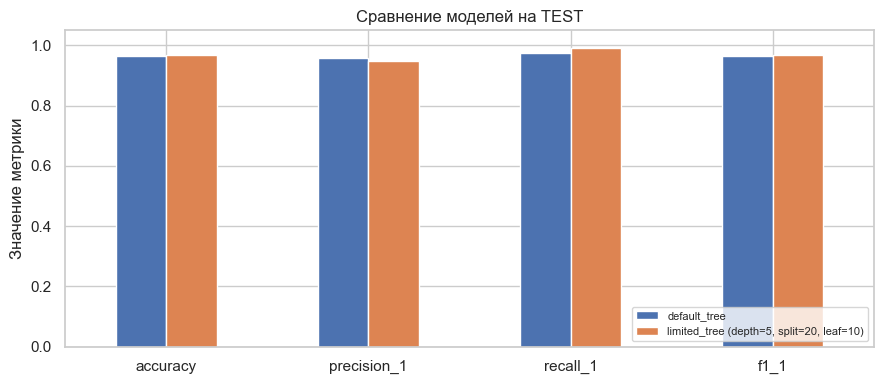

Разрыв Accuracy train−test:
  default:  0.0344
  limited:  0.0184


In [352]:
# 4.2. Визуальное сравнение метрик на test

# Какие метрики берём для графика (только test-метрики)
plot_cols = ["accuracy", "precision_1", "recall_1", "f1_1"]
# Делаем model индексом строк, оставляем нужные столбцы
comp_plot = compare.set_index("model")[plot_cols]

# Транспонируем: метрики по оси X, рядом столбцы двух моделей
ax = comp_plot.T.plot(kind="bar", figsize=(9, 4), rot=0)
# Метрики в долях от 0 до 1
ax.set_ylim(0, 1.05)
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение моделей на TEST")
# Легенда с именами моделей
ax.legend(loc="lower right", fontsize=8)
# Чтобы подписи не обрезались
plt.tight_layout()
plt.show()

# Разрывы train-test
print("Разрыв Accuracy train−test:")
print(f"  default:  {metrics_def['accuracy_train'] - metrics_def['accuracy']:.4f}")
print(f"  limited:  {metrics_lim['accuracy_train'] - metrics_lim['accuracy']:.4f}")


1. **Разрыв train−test уменьшился** (у limited он меньше, чем у default) — модель меньше «зазубривает» обучающую выборку.  
2. Дерево стало **проще** (меньше глубина и листьев) → его легче интерпретировать.

Итог: ограничения `max_depth` / `min_samples_*` — рабочий способ борьбы с переобучением на этой задаче. Дальше в п. 4.3 можно ещё подкрутить параметры через GridSearchCV.


In [353]:
# 4.3. GridSearchCV (поиск оптимальных параметров)

# Сетка значений гиперпараметров, которые переберём
param_grid = {
    "max_depth": [3, 5, 7, 10, None],          # None = без ограничения глубины
    "min_samples_split": [2, 10, 20, 50],      # минимум объектов для разбиения узла
    "min_samples_leaf": [1, 5, 10, 20],        # минимум объектов в листе
    "criterion": ["gini", "entropy"],           # критерий качества split'а
}

# GridSearchCV сам перебирает комбинации и оценивает каждую через кросс-валидацию
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),  # какую модель тюним
    param_grid=param_grid,                     # какие параметры перебирать
    scoring="f1",                              # критерий выбора: F1 для класса 1 (Approved)
    cv=StratifiedKFold(5, shuffle=True, random_state=42),  # 5 фолдов с сохранением баланса классов
    n_jobs=-1,                                 # использовать все ядра процессора
    refit=True,                                # после поиска заново обучить лучшую модель на всём train
)

# Запускаем перебор только на train (test не подглядываем)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

# Достаём уже обученную лучшую модель
tree_gs = grid.best_estimator_
# Предсказания лучшей модели на test и train
y_pred_gs = tree_gs.predict(X_test)
y_pred_train_gs = tree_gs.predict(X_train)

# Метрики для сравнения с default и limited
metrics_gs = eval_model(
    "gridsearch_best", y_test, y_pred_gs, y_train, y_pred_train_gs
)
# Три модели в одной таблице
compare2 = pd.DataFrame([metrics_def, metrics_lim, metrics_gs])
print()
print(compare2.round(4).to_string(index=False))


Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV F1: 0.9856

                                    model  accuracy  precision_1  recall_1   f1_1  accuracy_train  f1_1_train
                             default_tree    0.9656       0.9569    0.9749 0.9658          1.0000      1.0000
limited_tree (depth=5, split=20, leaf=10)    0.9687       0.9489    0.9906 0.9693          0.9871      0.9872
                          gridsearch_best    0.9718       0.9602    0.9843 0.9721          0.9926      0.9926



F1-score (F1) — одна метрика, которая совмещает Precision и Recall для выбранного класса. 

GridSearch **перебрал разные настройки** дерева и выбрал те, у которых лучше F1 на кросс-валидации.

**Итог:** GridSearch — удобный способ найти баланс между «слишком простым» и «переобученным» деревом. Ручные ограничения из п. 4.1 уже помогли; GridSearch может дать ещё небольшой выигрыш автоматически.


### Комментарий: как ограничения повлияли на модель (п.4)

- **`max_depth=5`** не даёт дереву вызубрить каждую заявку train.  
- **`min_samples_split` / `min_samples_leaf`** запрещают «мелкие» ветки на 1–2 объектах (шум).  
- Обычно **разрыв train−test уменьшается** (меньше переобучение).  
- Test-метрики могут чуть вырасти или остаться похожими, но модель становится **стабильнее и проще**.  
- GridSearch подбирает компромисс по CV (у нас ориентир — F1 для класса Approved).


# 5. Дополнительный анализ и выводы


Важные признаки (оптимизированная модель):
Credit_History                     0.9643
Applicant_Income                   0.0119
Coapplicant_Income                 0.0081
Employment_Status_Self-Employed    0.0056
Property_Area_Urban                0.0049
Loan_Amount                        0.0029
Education_Not Graduate             0.0018
Dependents                         0.0006


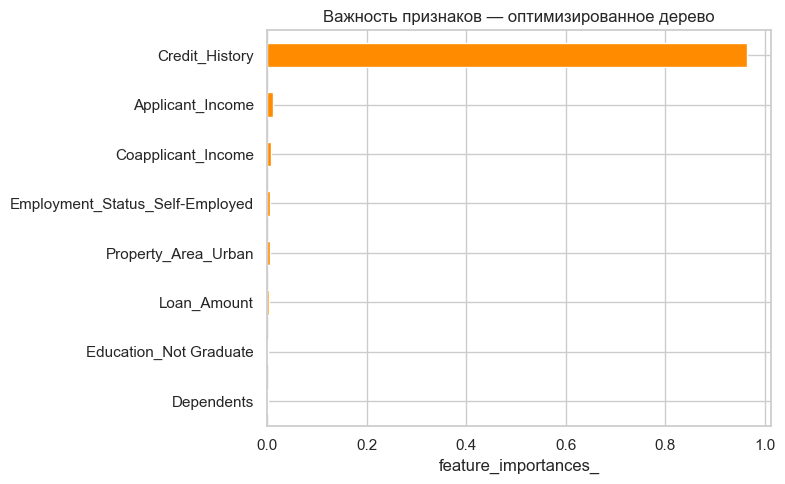

In [354]:
# 5.1. Важность признаков у оптимизированной модели
# Берём GridSearch-модель, если есть; иначе limited
best_model = tree_gs  # результат GridSearchCV; иначе используйте tree_lim

imp_best = pd.Series(best_model.feature_importances_, index=X.columns)
imp_best = imp_best[imp_best > 0].sort_values(ascending=False)

print("Важные признаки (оптимизированная модель):")
print(imp_best.round(4).to_string())

plt.figure(figsize=(8, 5))
imp_best.head(12).sort_values().plot(kind="barh", color="darkorange")
plt.title("Важность признаков — оптимизированное дерево")
plt.xlabel("feature_importances_")
plt.tight_layout()
plt.show()


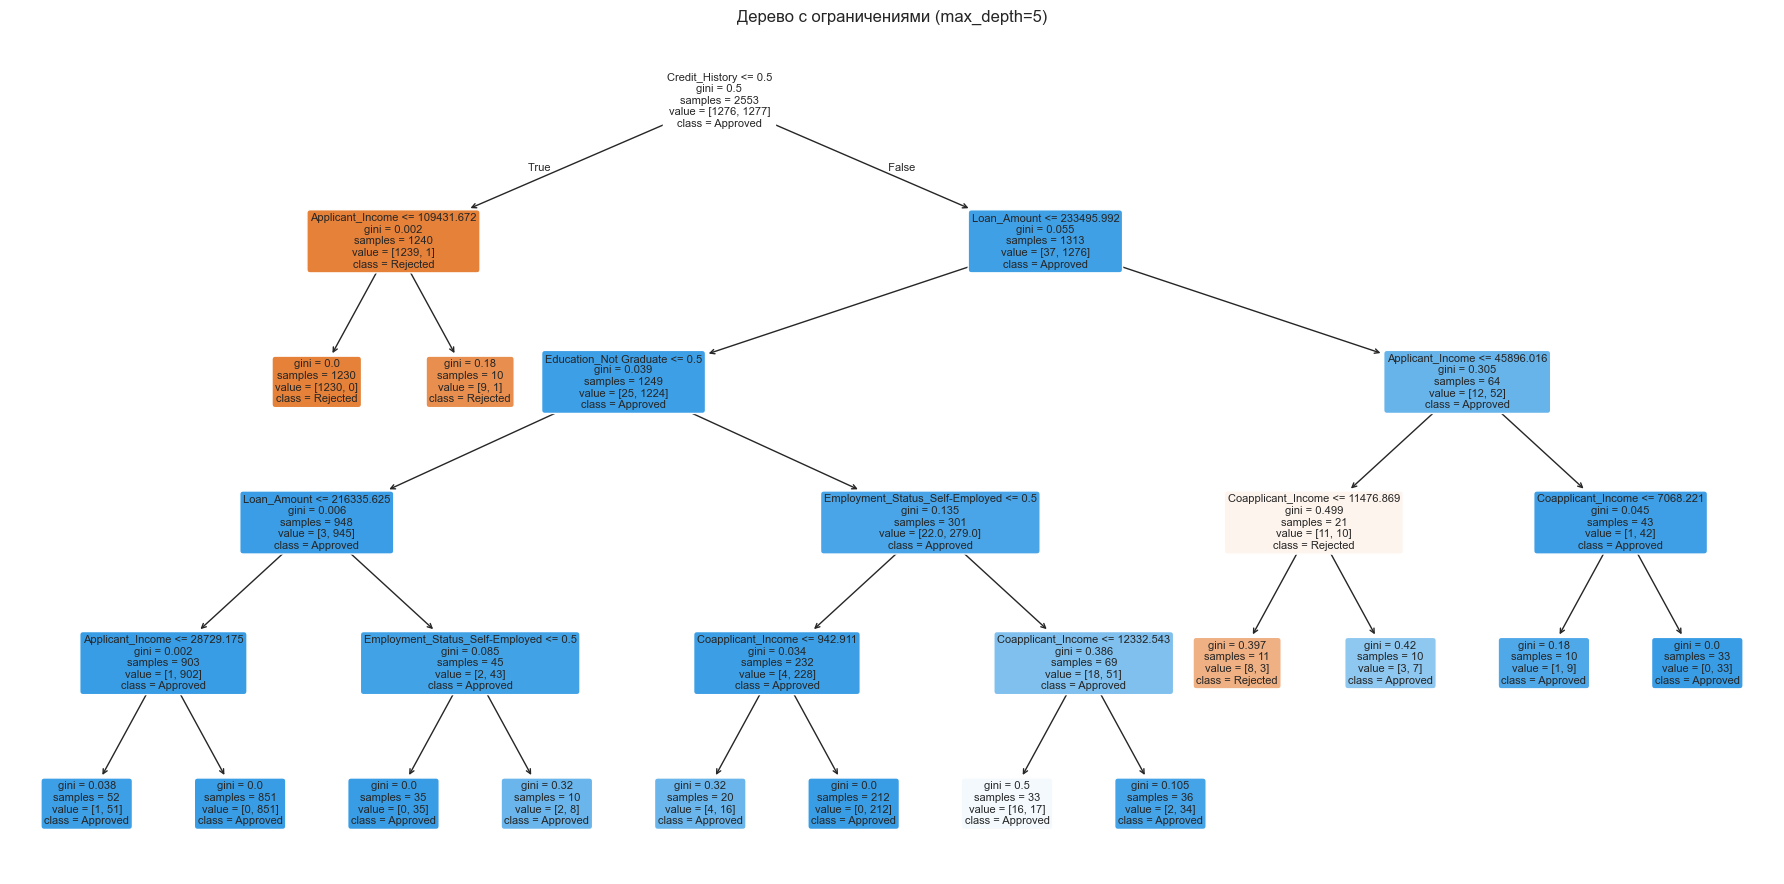

In [355]:
# 5.2. Визуализация ограниченного дерева (читаемая)
plt.figure(figsize=(18, 9))
plot_tree(
    tree_lim,
    feature_names=list(X.columns),
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Дерево с ограничениями (max_depth=5)")
plt.tight_layout()
plt.show()


## Итоговые выводы по работе

### Какие признаки наиболее значимы?
Кредитная история является ключевым признаком, но не гарантирует отказ. Для тех у кого ещё нет кредитной истории, смотрят уровень дохода и размер занимаемой суммы. Выгодно барть и выплачивать крдеиты для повышения своей кредитной истории.

### Как гиперпараметры повлияли на качество и интерпретируемость?
- Default-дерево: глубокое, почти идеальный train, хуже обобщение - это **переобучение**.  
- Ограничения / GridSearch: дерево **короче**, разрыв train/test **меньше**, структуру проще объяснить бизнесу.  

### Плюсы и минусы дерева на этой задаче
**Плюсы:** не требует масштабирования; хорошо ест смеси категорий/чисел после кодирования; правила читаемы; ловит нелинейности и пороги.  
**Минусы:** одно дерево нестабильно и легко переобучается; без ограничений качество на test проседает.

### Возможные улучшения
1. Ансамбли: **Random Forest**, **Gradient Boosting** (обычно сильнее одного дерева).  
2. Более аккуратная обработка пропусков / отдельный анализ флагов `*_was_missing`.  
3. Подбор метрики под бизнес (если дороже одобрить плохого заёмщика — смотреть precision/recall иначе).  
4. Кросс-валидация + калибровка вероятностей.  
5. Feature engineering: отношение `Loan_Amount / Applicant_Income`, суммарный доход семьи и т.п.

---